In [ ]:
#========================================================================
# Name: plot_fig_12_wrf_vs_obs_CTT_col_max_ref_LASSO.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
#
# Description: Compare WRF LASSO and observational cloud-top temperature
#              and column-maximum reflectivity at 2.5km resolution.
#========================================================================

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import datetime
import pandas as pd
import dask
from dask.distributed import wait
from distributed import Client, LocalCluster
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.colors as colors
import os

import warnings
warnings.filterwarnings("ignore")

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


# Start Dask Client

In [2]:
iparallel = True

In [3]:
if iparallel:
    dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 
    cluster = LocalCluster(n_workers=100,threads_per_worker=1)
    client = Client(cluster)

In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Workers: 100
Total threads: 100,Total memory: 476.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33277,Workers: 100
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Total threads: 100
Started: Just now,Total memory: 476.37 GiB
Comm: tcp://127.0.0.1:44823,Total threads: 1
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:36117/status,Memory: 4.76 GiB
Nanny: tcp://127.0.0.1:36267,


# Observations

In [2]:
obs_path = '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/'
obs_files = sorted(glob.glob(obs_path+'*.nc'))
num_obs_files = len(obs_files)
print(num_obs_files)

9


In [3]:
obs_files

['/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20181129.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20181204.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20181205.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20181219.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20190122.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20190123.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20190125.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20190129.nc',
 '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/2.5km/CSAPR_GOES_matched_times_2.5km_20190208.nc']

## Create pre-processing function that (1) retains only desired variables and (2) trims the domain to the region in which analysis is being performed

In [4]:
lonmin = -64.95
lonmax = -64.65
latmin = -32.9
latmax = -31.1
    
def preprocess_and_subset(ds_single):
    """
    Subsets variables and spatial domain for each file as it's opened.
    Crucially, it computes the boolean masks before using them.
    """
    keep_vars = [
        'ctt','lwp_iwp','opd','col_max_ref', 'ir_tb', 'cth', 'lon', 'lat'
    ]
    ds_single = ds_single[[v for v in keep_vars if v in ds_single]]

    if 'time' in ds_single.coords:
        ds_single['time'] = xr.decode_cf(ds_single).time
    
    # Replace with your actual dimension names
    dim_y = 'south_north'
    dim_x = 'west_east'

    # Create lazy 1D profiles
    mean_lon = ds_single['lon'].mean(dim=dim_y)
    mean_lat = ds_single['lat'].mean(dim=dim_x)

    # Create lazy boolean masks
    lon_mask = (mean_lon >= lonmin) & (mean_lon <= lonmax)
    lat_mask = (mean_lat >= latmin) & (mean_lat <= latmax)

    # ======================================================================
    #  THE FIX: Compute the masks to turn them from lazy Dask arrays
    #  into concrete NumPy boolean arrays before indexing.
    # ======================================================================
    lon_mask_computed = lon_mask.compute()
    lat_mask_computed = lat_mask.compute()
    
    # Now use the computed NumPy masks for subsetting.
    # This works because xarray knows the exact shape of the output.
    ds_trimmed = ds_single.isel(
        {dim_x: lon_mask_computed, dim_y: lat_mask_computed}
    )
    
    return ds_trimmed

## Load data

In [12]:
print("--- Opening and subsetting OBS dataset ---")
ds_obs = xr.open_mfdataset(
    obs_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=preprocess_and_subset,
    combine_attrs="override"  # Good practice when preprocessing
)
ds_obs = ds_obs.sortby('time')

--- Opening and subsetting OBS dataset ---


In [13]:
ds_obs

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 395, south_north: 78, west_east: 11)
Coordinates:
    lon          (south_north, west_east) float64 7kB dask.array<chunksize=(78, 11), meta=np.ndarray>
    lat          (south_north, west_east) float64 7kB dask.array<chunksize=(78, 11), meta=np.ndarray>
  * time         (time) int64 3kB 1543492803 1543493703 ... 1549657803
Dimensions without coordinates: south_north, west_east
Data variables:
    ctt          (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 78, 11), meta=np.ndarray>
    lwp_iwp      (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 78, 11), meta=np.ndarray>
    opd          (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 78, 11), meta=np.ndarray>
    col_max_ref  (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 78, 11), meta=np.ndarray>
    ir_tb        (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 78, 11), meta=np.ndarray>
    cth          (time, south_north, west_east) float32 1MB dask.array<chunksize=(1, 78, 11), meta=np.ndarray>
Attributes:
    title:              Matched-time GOES & CSAPR datasets coarse-grained to ...
    Institution:        Pacific Northwest National Laboratoy
    Contact:            McKenna Stanford, mckenna.stnaford@pnnl.gov
    Created_on:         Mon Dec 29 19:22:18 2025
    source_csapr_path:  /pscratch/sd/m/mckenna/cacti/csapr_regridded/
    source_goes_path:   /pscratch/sd/m/mckenna/cacti/satcorps_regridded/
    Date:               20181129

## Get only points where CTT is not NaN and flatten arrays to be in a Pandas dataframe

In [14]:
# 1. Create a lazy boolean mask for all valid 'ctt' values.
#    .notnull() is the idiomatic xarray way to check for non-NaN values.
valid_ctt_mask = ds_obs['ctt'].notnull()

In [15]:
# 2. Apply the mask to the dataset, but WITHOUT `drop=True`.
#    This operation IS supported by Dask. It keeps the original shape,
#    but lazily inserts `NaN` where the mask is False.
#    This makes all variables (opd, ref, etc.) NaN where ctt is NaN.
ds_filtered_with_nans = ds_obs.where(valid_ctt_mask)

In [16]:
# 3. Convert the lazy dataset to a pandas DataFrame.
#    THIS IS THE MAGIC STEP.
#    By default, `to_dataframe()` automatically drops rows where ALL data
#    variables are NaN. Since our `.where()` call created these all-NaN
#    "pixels", they will be efficiently discarded during the conversion process.
#    This step triggers the Dask computation.
print("\n--- Triggering computation and converting to DataFrame... ---")
df_obs = ds_filtered_with_nans.to_dataframe()
df_obs = df_obs.dropna(subset=['ctt'])


--- Triggering computation and converting to DataFrame... ---


In [17]:
df_obs

ctt     lwp_iwp        opd  \
time       south_north west_east                                     
1543492803 0           9           6.179718   10.072371   0.800906   
                       10        -22.932983    5.494036   1.015783   
           1           6           7.388397    8.424170   1.933892   
                       7           1.954865   16.848309   2.847117   
                       8           6.179718   10.072371   0.800906   
...                                     ...         ...        ...   
1549657803 77          6           8.712463  135.518753  30.893389   
                       7          11.525391   32.597782   6.744196   
                       8          11.953918   28.202578   6.675827   
                       9           9.492615   36.077316   8.990632   
                       10          7.525757   72.704002  16.408756   

                                  col_max_ref      ir_tb       cth        lon  \
time       south_north west_east                                                
1543492803 0           9                  NaN  11.167084  2.883131 -64.690920   
                       10                 NaN   1.497620  7.070781 -64.664149   
           1           6                  NaN   9.537201  2.712206 -64.771223   
                       7                  NaN   4.000458  3.537528 -64.744459   
                       8                  NaN  11.167084  2.883131 -64.717694   
...                                       ...        ...       ...        ...   
1549657803 77          6                  NaN   7.992767  3.502122 -64.770432   
                       7                  NaN  10.837433  3.001557 -64.744162   
                       8                  NaN  11.240326  2.928914 -64.717892   
                       9                  NaN   8.798553  3.360498 -64.691622   
                       10                 NaN   6.790192  3.717609 -64.665352   

                                        lat  
time       south_north west_east             
1543492803 0           9         -32.881825  
                       10        -32.881814  
           1           6         -32.859340  
                       7         -32.859346  
                       8         -32.859347  
...                                     ...  
1549657803 77          6         -31.150629  
                       7         -31.150635  
                       8         -31.150635  
                       9         -31.150630  
                       10        -31.150620  

[250817 rows x 8 columns]

## Save to pickle file

In [18]:
# To save the DataFrame to a pickle file
save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_obs.to_pickle(save_path+"LASSO_obs_ctt_filtered_df.pkl")

## Load pickle file

In [2]:
in_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_obs = pd.read_pickle(in_path+"LASSO_obs_ctt_filtered_df.pkl")

In [6]:
print(np.min(df_obs['lon'].values))
print(np.max(df_obs['lon'].values))
print(np.min(df_obs['lat'].values))
print(np.max(df_obs['lat'].values))
print(np.min(df_obs['cth'].values))
print(np.max(df_obs['cth'].values))

-64.93186230120456
-64.66414867677796
-32.88183005464061
-31.15047871325122
0.92360324
18.710741


## Calculate and plot probability of preciptiation

In [3]:
# Assume 'df_obs_final' is your clean DataFrame from the previous step
# Apply the initial filter for optically thick clouds
df_plot_obs = df_obs[df_obs['opd'] > 10.0].copy()

# For the CTH plot, your original code had a different filter.
# We'll create a separate DataFrame for that.
df_plot_obs_cth = df_obs[(df_obs['opd'] > 10.0) & (df_obs['cth'] >= 0.5)].copy()

In [4]:
def plot_precip_prob(ax, df, variable_to_bin, bins, xlabel, ref_threshes):
    """
    Calculates and plots precipitation probability for a given variable.
    (Corrected version to handle empty bins)
    """
    Fontsize = 11

    # 1. BIN THE DATA (same as before)
    # The labels are the integer index of the bin, from 0 to N-1
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)

    # ======================================================================
    #  THE FIX, PART 1: Convert the bin column to a categorical type.
    #  This tells pandas about all possible bins that *could* exist.
    # ======================================================================
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)

    # 2. CALCULATE PROBABILITIES using pandas.groupby
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref', 
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    aggs['count'] = pd.NamedAgg(column='col_max_ref', aggfunc='size')
    
    # ======================================================================
    #  THE FIX, PART 2: Use `observed=False` in the groupby.
    #  This forces pandas to create a row for EVERY category (bin),
    #  even if it's empty in the data.
    # ======================================================================
    binned_stats = df.groupby('bin', observed=False).agg(**aggs)
    
    # Empty bins will result in NaN for the mean and 0 for the count.
    # We should fill the NaN probabilities with 0.
    binned_stats = binned_stats.fillna(0)

    # Now, binned_stats is guaranteed to have the same number of rows
    # as there are bins, so the next step will work perfectly.
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers

    # 3. PLOT THE RESULTS (this part remains the same)
    colors = ['red','darkorange','gold','green','deepskyblue','blue']
    
    for i, thresh in enumerate(ref_threshes):
        ax.plot(binned_stats['bin_centers'], binned_stats[f'prob_{thresh}'], 
                lw=2, c=colors[i], label=f'{thresh} dBZ')

    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
    ax.set_xlabel(xlabel, fontsize=Fontsize)
    ax.set_ylim(0)

    ax_hist = ax.twinx()
    
    # 1. Manually calculate the histogram data
    valid_data_for_hist = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(
        valid_data_for_hist[variable_to_bin], 
        bins=bins, 
        density=True
    )
    
    # 2. Plot the result as a Line2D object using ax.plot
    #    'drawstyle="steps-post"' creates the classic histogram shape.
    #    Now, `lw` will have a very clear and predictable effect.
    ax_hist.plot(bin_edges, np.append(counts, counts[-1]), 
                 drawstyle='steps-post', color='k', lw=2, label='PDF')

    
    # We need to drop rows with 0 count for the histogram to be accurate
    # as the original df has NaNs for bins that are out of range
    #valid_data_for_hist = df.dropna(subset=['bin'])
    #ax_hist.hist(valid_data_for_hist[variable_to_bin], bins=bins, histtype='step', 
    #             lw=2, color='k', density=True, label='PDF')
    ax_hist.tick_params(labelsize=Fontsize)
    ax_hist.set_ylabel(f'{variable_to_bin.upper()} Probability Density', fontsize=Fontsize)


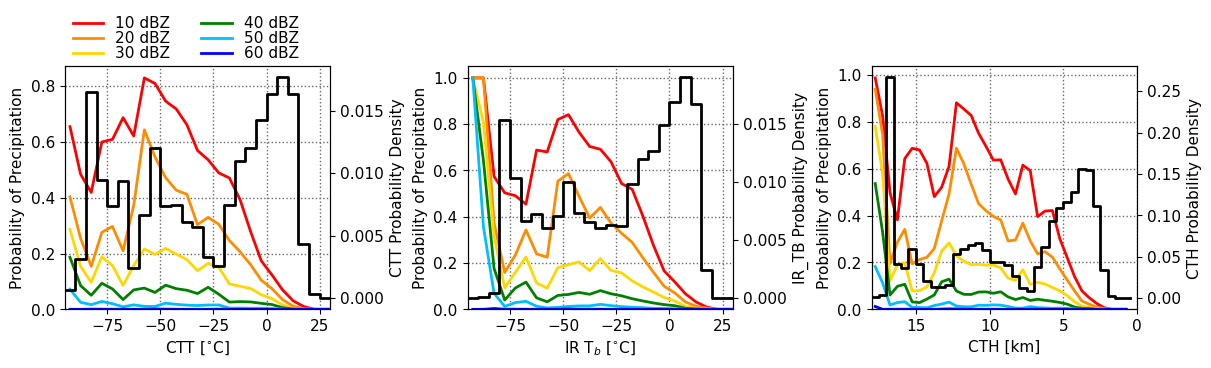

In [5]:
# Define settings
ref_threshes = np.arange(10, 70, 10)
ctt_bins = np.arange(-95, 45, 5)
ir_tb_bins = np.arange(-95, 45, 5)
cth_bins = np.arange(0.5, 18.5, 0.5)

# Create the figure and axes
fig = plt.figure(figsize=(12, 3), constrained_layout=True)
ax1, ax2, ax3 = fig.subplots(1, 3)

# --- Call the function for each subplot ---
plot_precip_prob(ax1, df_plot_obs, 'ctt', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

plot_precip_prob(ax2, df_plot_obs, 'ir_tb', ir_tb_bins, 
                 'IR T$_{b}$ [$^{\\circ}$C]', ref_threshes)

plot_precip_prob(ax3, df_plot_obs_cth, 'cth', cth_bins, 
                 'CTH [km]', ref_threshes)

# --- Final plot adjustments ---
ax1.set_xlim(-95, 30)
ax2.set_xlim(-95, 30)
ax3.set_xlim(0, 18)
ax3.invert_xaxis() # Special case for CTH plot

# Add a single legend to the first plot
lines, labels = ax1.get_legend_handles_labels()
fig.legend(lines, labels, fontsize=11, framealpha=False, 
           bbox_to_anchor=(0.15, 1.2), loc='upper center', ncol=2,labelspacing=0.01)

plt.show()
plt.close()

# WRF

In [11]:
# Your base directory
wrf_path = '/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/'

# --- The New Search Pattern ---
# We build a pattern that describes the nested structure.
# '**' is a special wildcard that matches zero or more directories.

# os.path.join is the best practice for building paths.
# It will construct: '/path/to/base/**/derived/WRF_CACTI_3km_derived_*.nc'
search_pattern = os.path.join(wrf_path, '**', 'derived', 'LASSO_CACTI_2.5km_derived_*.nc')

print(f"Using search pattern: {search_pattern}\n")

# Use glob.glob with the recursive flag set to True
# The output is not guaranteed to be sorted, so we wrap it in sorted()
wrf_files = sorted(glob.glob(search_pattern, recursive=True))

num_wrf_files = len(wrf_files)
print(f'# of files found: {num_wrf_files}')

# Print the first 5 files to verify the paths are correct
if num_wrf_files > 0:
    print("\nExample files found:")
    for f in wrf_files[:5]:
        print(f)

Using search pattern: /pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/**/derived/LASSO_CACTI_2.5km_derived_*.nc

# of files found: 1168

Example files found:
/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d2/derived/LASSO_CACTI_2.5km_derived_20181129_12:00:00_gefs03_d2_native.nc
/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d2/derived/LASSO_CACTI_2.5km_derived_20181129_12:15:00_gefs03_d2_native.nc
/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d2/derived/LASSO_CACTI_2.5km_derived_20181129_12:30:00_gefs03_d2_native.nc
/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d2/derived/LASSO_CACTI_2.5km_derived_20181129_12:45:00_gefs03_d2_native.nc
/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d2/derived/LASSO_CACTI_2.5km_derived_20181129_13:00:00_gefs03_d2_native.nc


In [12]:
import glob
import os
from collections import defaultdict

# Your base directory
wrf_path = '/pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/'

# The general search pattern to find all relevant files across all domains
search_pattern = os.path.join(wrf_path, '**', 'derived', 'LASSO_CACTI_2.5km_derived_*.nc')

print(f"Using search pattern: {search_pattern}\n")

# 1. Get a single, sorted list of all files from all domains
all_wrf_files = sorted(glob.glob(search_pattern, recursive=True))

# 2. Initialize a dictionary to hold the lists for each domain.
#    Using defaultdict makes the loop cleaner, but a regular dict works too.
wrf_files_by_domain = defaultdict(list)

# Define the domains you care about
domains = ['d2', 'd3', 'd4']

# 3. Loop through the master list and sort each file into the correct list
for file_path in all_wrf_files:
    # Check which domain this file path belongs to
    if f'/d2/' in file_path:
        wrf_files_by_domain['d2'].append(file_path)
    elif f'/d3/' in file_path:
        wrf_files_by_domain['d3'].append(file_path)
    elif f'/d4/' in file_path:
        wrf_files_by_domain['d4'].append(file_path)

# 4. (Optional) You can now access the individual lists easily
d2_files = wrf_files_by_domain['d2']
d3_files = wrf_files_by_domain['d3']
d4_files = wrf_files_by_domain['d4']

# --- Verification ---
print(f"# of d2 files found: {len(d2_files)}")
print(f"# of d3 files found: {len(d3_files)}")
print(f"# of d4 files found: {len(d4_files)}")
print("-" * 20)
print(f"Total files sorted: {len(d2_files) + len(d3_files) + len(d4_files)}")
print(f"Total files found initially: {len(all_wrf_files)}")

# Print an example from each list to confirm
if d2_files:
    print(f"\nExample d2 file: {d2_files[0]}")
if d3_files:
    print(f"Example d3 file: {d3_files[0]}")
if d4_files:
    print(f"Example d4 file: {d4_files[0]}")

Using search pattern: /pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/**/derived/LASSO_CACTI_2.5km_derived_*.nc

# of d2 files found: 392
# of d3 files found: 384
# of d4 files found: 392
--------------------
Total files sorted: 1168
Total files found initially: 1168

Example d2 file: /pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d2/derived/LASSO_CACTI_2.5km_derived_20181129_12:00:00_gefs03_d2_native.nc
Example d3 file: /pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d3/derived/LASSO_CACTI_2.5km_derived_20181129_12:15:00_gefs03_d3_native.nc
Example d4 file: /pscratch/sd/m/mckenna/wrf_lasso/coarse_grained/20181129/gefs03/d4/derived/LASSO_CACTI_2.5km_derived_20181129_12:00:00_gefs03_d4_native.nc


In [13]:
lonmin = -64.95
lonmax = -64.65
latmin = -32.9
latmax = -31.1
    
def preprocess_and_subset_wrf(ds_single):
    """
    Subsets variables and spatial domain for each file as it's opened.
    Crucially, it computes the boolean masks before using them.
    """
    keep_vars = [
        'opd_vis','opd_ir','ctt_tau_vis','ctt_tau_ir','col_max_ref', 'ir_tb', 'cth', 'lon', 'lat','twp',
        'cth_tau_vis','cth_tau_ir','ctt_tau_50_50','cth_tau_50_50','opd_50_50'
    ]
    ds_single = ds_single[[v for v in keep_vars if v in ds_single]]

    if 'time' in ds_single.coords:
        ds_single['time'] = xr.decode_cf(ds_single).time
    
    # Replace with your actual dimension names
    dim_y = 'south_north'
    dim_x = 'west_east'

    # Create lazy 1D profiles
    mean_lon = ds_single['lon'].mean(dim=dim_y)
    mean_lat = ds_single['lat'].mean(dim=dim_x)

    # Create lazy boolean masks
    lon_mask = (mean_lon >= lonmin) & (mean_lon <= lonmax)
    lat_mask = (mean_lat >= latmin) & (mean_lat <= latmax)

    # ======================================================================
    #  THE FIX: Compute the masks to turn them from lazy Dask arrays
    #  into concrete NumPy boolean arrays before indexing.
    # ======================================================================
    lon_mask_computed = lon_mask.compute()
    lat_mask_computed = lat_mask.compute()
    
    # Now use the computed NumPy masks for subsetting.
    # This works because xarray knows the exact shape of the output.
    ds_trimmed = ds_single.isel(
        {dim_x: lon_mask_computed, dim_y: lat_mask_computed}
    )
    
    return ds_trimmed

In [14]:
print("--- Opening and subsetting WRF dataset ---")
ds_wrf_d2 = xr.open_mfdataset(
    d2_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=preprocess_and_subset_wrf,
    combine_attrs="override"  # Good practice when preprocessing
)
ds_wrf_d2 = ds_wrf_d2.sortby('time')

--- Opening and subsetting WRF dataset ---


In [15]:
print("--- Opening and subsetting WRF dataset ---")
ds_wrf_d3 = xr.open_mfdataset(
    d3_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=preprocess_and_subset_wrf,
    combine_attrs="override"  # Good practice when preprocessing
)
ds_wrf_d3 = ds_wrf_d3.sortby('time')

--- Opening and subsetting WRF dataset ---


In [16]:
print("--- Opening and subsetting WRF dataset ---")
ds_wrf_d4 = xr.open_mfdataset(
    d4_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=preprocess_and_subset_wrf,
    combine_attrs="override"  # Good practice when preprocessing
)
ds_wrf_d4 = ds_wrf_d4.sortby('time')

--- Opening and subsetting WRF dataset ---


In [17]:
# 1. Create a lazy boolean mask for all valid 'ctt' values.
#    .notnull() is the idiomatic xarray way to check for non-NaN values.
valid_ctt_ir_mask_wrf = ds_wrf_d2['ctt_tau_ir'].notnull()
valid_ctt_vis_mask_wrf = ds_wrf_d2['ctt_tau_vis'].notnull()
valid_ctt_visir5050_mask_wrf = ds_wrf_d2['ctt_tau_50_50'].notnull()

# 2. Apply the mask to the dataset, but WITHOUT `drop=True`.
#    This operation IS supported by Dask. It keeps the original shape,
#    but lazily inserts `NaN` where the mask is False.
#    This makes all variables (opd, ref, etc.) NaN where ctt is NaN.
ds_wrf_filtered_with_nans_vis = ds_wrf_d2.where(valid_ctt_ir_mask_wrf)
ds_wrf_filtered_with_nans_ir = ds_wrf_d2.where(valid_ctt_vis_mask_wrf)
ds_wrf_filtered_with_nans_visir5050 = ds_wrf_d2.where(valid_ctt_visir5050_mask_wrf)

df_wrf_ir = ds_wrf_filtered_with_nans_ir.to_dataframe()
df_wrf_ir = df_wrf_ir.dropna(subset=['ctt_tau_ir'])

df_wrf_vis = ds_wrf_filtered_with_nans_vis.to_dataframe()
df_wrf_vis = df_wrf_vis.dropna(subset=['ctt_tau_vis'])

df_wrf_visir5050 = ds_wrf_filtered_with_nans_visir5050.to_dataframe()
df_wrf_visir5050 = df_wrf_visir5050.dropna(subset=['ctt_tau_50_50'])

save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_wrf_vis.to_pickle(save_path+f"LASSO_wrf_vis_ctt_filtered_df_d2.pkl")
df_wrf_ir.to_pickle(save_path+f"LASSO_wrf_ir_ctt_filtered_df_d2.pkl")
df_wrf_visir5050.to_pickle(save_path+f"LASSO_wrf_visir5050_ctt_filtered_df_d2.pkl")

In [18]:
# 1. Create a lazy boolean mask for all valid 'ctt' values.
#    .notnull() is the idiomatic xarray way to check for non-NaN values.
valid_ctt_ir_mask_wrf = ds_wrf_d3['ctt_tau_ir'].notnull()
valid_ctt_vis_mask_wrf = ds_wrf_d3['ctt_tau_vis'].notnull()
valid_ctt_visir5050_mask_wrf = ds_wrf_d3['ctt_tau_50_50'].notnull()

# 2. Apply the mask to the dataset, but WITHOUT `drop=True`.
#    This operation IS supported by Dask. It keeps the original shape,
#    but lazily inserts `NaN` where the mask is False.
#    This makes all variables (opd, ref, etc.) NaN where ctt is NaN.
ds_wrf_filtered_with_nans_vis = ds_wrf_d3.where(valid_ctt_ir_mask_wrf)
ds_wrf_filtered_with_nans_ir = ds_wrf_d3.where(valid_ctt_vis_mask_wrf)
ds_wrf_filtered_with_nans_visir5050 = ds_wrf_d3.where(valid_ctt_visir5050_mask_wrf)

df_wrf_ir = ds_wrf_filtered_with_nans_ir.to_dataframe()
df_wrf_ir = df_wrf_ir.dropna(subset=['ctt_tau_ir'])

df_wrf_vis = ds_wrf_filtered_with_nans_vis.to_dataframe()
df_wrf_vis = df_wrf_vis.dropna(subset=['ctt_tau_vis'])

df_wrf_visir5050 = ds_wrf_filtered_with_nans_visir5050.to_dataframe()
df_wrf_visir5050 = df_wrf_visir5050.dropna(subset=['ctt_tau_50_50'])

save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_wrf_vis.to_pickle(save_path+f"LASSO_wrf_vis_ctt_filtered_df_d3.pkl")
df_wrf_ir.to_pickle(save_path+f"LASSO_wrf_ir_ctt_filtered_df_d3.pkl")
df_wrf_visir5050.to_pickle(save_path+f"LASSO_wrf_visir5050_ctt_filtered_df_d3.pkl")

In [19]:
# 1. Create a lazy boolean mask for all valid 'ctt' values.
#    .notnull() is the idiomatic xarray way to check for non-NaN values.
valid_ctt_ir_mask_wrf = ds_wrf_d4['ctt_tau_ir'].notnull()
valid_ctt_vis_mask_wrf = ds_wrf_d4['ctt_tau_vis'].notnull()
valid_ctt_visir5050_mask_wrf = ds_wrf_d4['ctt_tau_50_50'].notnull()

# 2. Apply the mask to the dataset, but WITHOUT `drop=True`.
#    This operation IS supported by Dask. It keeps the original shape,
#    but lazily inserts `NaN` where the mask is False.
#    This makes all variables (opd, ref, etc.) NaN where ctt is NaN.
ds_wrf_filtered_with_nans_vis = ds_wrf_d4.where(valid_ctt_ir_mask_wrf)
ds_wrf_filtered_with_nans_ir = ds_wrf_d4.where(valid_ctt_vis_mask_wrf)
ds_wrf_filtered_with_nans_visir5050 = ds_wrf_d4.where(valid_ctt_visir5050_mask_wrf)

df_wrf_ir = ds_wrf_filtered_with_nans_ir.to_dataframe()
df_wrf_ir = df_wrf_ir.dropna(subset=['ctt_tau_ir'])

df_wrf_vis = ds_wrf_filtered_with_nans_vis.to_dataframe()
df_wrf_vis = df_wrf_vis.dropna(subset=['ctt_tau_vis'])

df_wrf_visir5050 = ds_wrf_filtered_with_nans_visir5050.to_dataframe()
df_wrf_visir5050 = df_wrf_visir5050.dropna(subset=['ctt_tau_50_50'])

save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_wrf_vis.to_pickle(save_path+f"LASSO_wrf_vis_ctt_filtered_df_d4.pkl")
df_wrf_ir.to_pickle(save_path+f"LASSO_wrf_ir_ctt_filtered_df_d4.pkl")
df_wrf_visir5050.to_pickle(save_path+f"LASSO_wrf_visir5050_ctt_filtered_df_d4.pkl")

In [6]:
in_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_wrf_vis_d2 = pd.read_pickle(in_path+"LASSO_wrf_vis_ctt_filtered_df_d2.pkl")
df_wrf_ir_d2 = pd.read_pickle(in_path+"LASSO_wrf_ir_ctt_filtered_df_d2.pkl")
df_wrf_visir5050_d2 = pd.read_pickle(in_path+"LASSO_wrf_visir5050_ctt_filtered_df_d2.pkl")

df_wrf_vis_d3 = pd.read_pickle(in_path+"LASSO_wrf_vis_ctt_filtered_df_d3.pkl")
df_wrf_ir_d3 = pd.read_pickle(in_path+"LASSO_wrf_ir_ctt_filtered_df_d3.pkl")
df_wrf_visir5050_d3 = pd.read_pickle(in_path+"LASSO_wrf_visir5050_ctt_filtered_df_d3.pkl")

df_wrf_vis_d4 = pd.read_pickle(in_path+"LASSO_wrf_vis_ctt_filtered_df_d4.pkl")
df_wrf_ir_d4 = pd.read_pickle(in_path+"LASSO_wrf_ir_ctt_filtered_df_d4.pkl")
df_wrf_visir5050_d4 = pd.read_pickle(in_path+"LASSO_wrf_visir5050_ctt_filtered_df_d4.pkl")

# Begin here

In [11]:
#df_wrf_ir

In [7]:
df_plot_wrf_vis_d2 = df_wrf_vis_d2[df_wrf_vis_d2['opd_vis'] > 10.0].copy()
df_plot_wrf_vis_cth_d2 = df_wrf_vis_d2[(df_wrf_vis_d2['opd_vis'] > 10.0) & (df_wrf_vis_d2['cth_tau_vis'] >= 0.5)].copy()

df_plot_wrf_ir_d2 = df_wrf_ir_d2[df_wrf_ir_d2['opd_vis'] > 10.0].copy()
df_plot_wrf_ir_cth_d2 = df_wrf_ir_d2[(df_wrf_ir_d2['opd_vis'] > 10.0) & (df_wrf_ir_d2['cth_tau_ir'] >= 0.5)].copy()

df_plot_wrf_visir5050_d2 = df_wrf_visir5050_d2[df_wrf_visir5050_d2['opd_vis'] > 10.0].copy()
df_plot_wrf_visir5050_cth_d2 = df_wrf_visir5050_d2[(df_wrf_visir5050_d2['opd_vis'] > 10.0) & (df_wrf_visir5050_d2['cth_tau_ir'] >= 0.5)].copy()

In [8]:
df_plot_wrf_vis_d3 = df_wrf_vis_d3[df_wrf_vis_d3['opd_vis'] > 10.0].copy()
df_plot_wrf_vis_cth_d3 = df_wrf_vis_d3[(df_wrf_vis_d3['opd_vis'] > 10.0) & (df_wrf_vis_d3['cth_tau_vis'] >= 0.5)].copy()

df_plot_wrf_ir_d3 = df_wrf_ir_d3[df_wrf_ir_d3['opd_vis'] > 10.0].copy()
df_plot_wrf_ir_cth_d3 = df_wrf_ir_d3[(df_wrf_ir_d3['opd_vis'] > 10.0) & (df_wrf_ir_d3['cth_tau_ir'] >= 0.5)].copy()

df_plot_wrf_visir5050_d3 = df_wrf_visir5050_d3[df_wrf_visir5050_d3['opd_vis'] > 10.0].copy()
df_plot_wrf_visir5050_cth_d3 = df_wrf_visir5050_d3[(df_wrf_visir5050_d3['opd_vis'] > 10.0) & (df_wrf_visir5050_d3['cth_tau_ir'] >= 0.5)].copy()

In [9]:
df_plot_wrf_vis_d4 = df_wrf_vis_d4[df_wrf_vis_d4['opd_vis'] > 10.0].copy()
df_plot_wrf_vis_cth_d4 = df_wrf_vis_d4[(df_wrf_vis_d4['opd_vis'] > 10.0) & (df_wrf_vis_d4['cth_tau_vis'] >= 0.5)].copy()

df_plot_wrf_ir_d4 = df_wrf_ir_d4[df_wrf_ir_d4['opd_vis'] > 10.0].copy()
df_plot_wrf_ir_cth_d4 = df_wrf_ir_d4[(df_wrf_ir_d4['opd_vis'] > 10.0) & (df_wrf_ir_d4['cth_tau_ir'] >= 0.5)].copy()

df_plot_wrf_visir5050_d4 = df_wrf_visir5050_d4[df_wrf_visir5050_d4['opd_vis'] > 10.0].copy()
df_plot_wrf_visir5050_cth_d4 = df_wrf_visir5050_d4[(df_wrf_visir5050_d4['opd_vis'] > 10.0) & (df_wrf_visir5050_d4['cth_tau_ir'] >= 0.5)].copy()

In [10]:
def plot_precip_prob(ax, df, variable_to_bin, bins, xlabel, ref_threshes):
    """
    Calculates and plots precipitation probability for a given variable.
    (Corrected version to handle empty bins)
    """
    Fontsize = 11

    # 1. BIN THE DATA (same as before)
    # The labels are the integer index of the bin, from 0 to N-1
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)

    # ======================================================================
    #  THE FIX, PART 1: Convert the bin column to a categorical type.
    #  This tells pandas about all possible bins that *could* exist.
    # ======================================================================
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)

    # 2. CALCULATE PROBABILITIES using pandas.groupby
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref', 
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    aggs['count'] = pd.NamedAgg(column='col_max_ref', aggfunc='size')
    
    # ======================================================================
    #  THE FIX, PART 2: Use `observed=False` in the groupby.
    #  This forces pandas to create a row for EVERY category (bin),
    #  even if it's empty in the data.
    # ======================================================================
    binned_stats = df.groupby('bin', observed=False).agg(**aggs)
    
    # Empty bins will result in NaN for the mean and 0 for the count.
    # We should fill the NaN probabilities with 0.
    binned_stats = binned_stats.fillna(0)

    # Now, binned_stats is guaranteed to have the same number of rows
    # as there are bins, so the next step will work perfectly.
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers

    # 3. PLOT THE RESULTS (this part remains the same)
    colors = ['red','darkorange','gold','green','deepskyblue','blue']
    
    for i, thresh in enumerate(ref_threshes):
        ax.plot(binned_stats['bin_centers'], binned_stats[f'prob_{thresh}'], 
                lw=2, c=colors[i], label=f'{thresh} dBZ')

    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    #ax.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
    ax.set_xlabel(xlabel, fontsize=Fontsize)
    ax.set_ylim(0)

    ax_hist = ax.twinx()
    
    # 1. Manually calculate the histogram data
    valid_data_for_hist = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(
        valid_data_for_hist[variable_to_bin], 
        bins=bins, 
        density=True
    )
    
    # 2. Plot the result as a Line2D object using ax.plot
    #    'drawstyle="steps-post"' creates the classic histogram shape.
    #    Now, `lw` will have a very clear and predictable effect.
    ax_hist.plot(bin_edges, np.append(counts, counts[-1]), 
                 drawstyle='steps-post', color='k', lw=2, label='PDF')

    
    # We need to drop rows with 0 count for the histogram to be accurate
    # as the original df has NaNs for bins that are out of range
    #valid_data_for_hist = df.dropna(subset=['bin'])
    #ax_hist.hist(valid_data_for_hist[variable_to_bin], bins=bins, histtype='step', 
    #             lw=2, color='k', density=True, label='PDF')
    ax_hist.tick_params(labelsize=Fontsize)
    #ax_hist.set_ylabel(f'{variable_to_bin.upper()} Probability Density', fontsize=Fontsize)
    #ax_hist.set_ylabel(f'CTT Probability Density', fontsize=Fontsize)
    return ax_hist

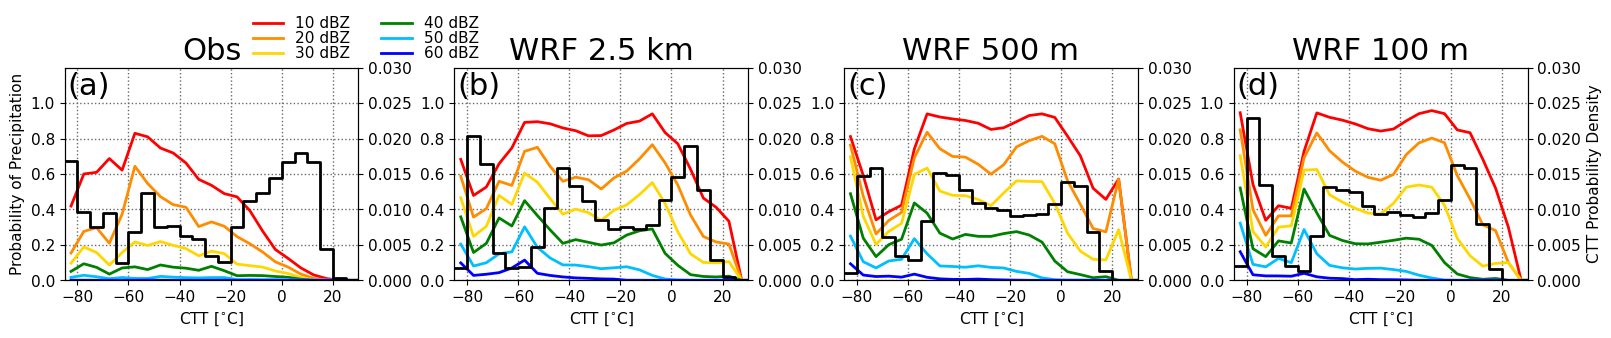

In [11]:
# Define settings
ref_threshes = np.arange(10, 70, 10)
ctt_bins = np.arange(-85, 45, 5)
ir_tb_bins = np.arange(-85, 45, 5)
cth_bins = np.arange(0.5, 18.5, 0.5)

# Create the figure and axes
fig = plt.figure(figsize=(16, 3), constrained_layout=True)
ax1, ax2, ax3, ax4 = fig.subplots(1, 4)
axlist = [ax1,ax2,ax3,ax4]

# --- Call the function for each subplot ---
ax_hist1 = plot_precip_prob(ax1, df_plot_obs, 'ctt', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)
#ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_vis_d2, 'ctt_tau_vis', ctt_bins, 
ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, 
#ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_visir5050_d2, 'ctt_tau_50_50', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

#ax_hist3 = plot_precip_prob(ax2, df_plot_wrf_vis_d3, 'ctt_tau_vis', ctt_bins, 
ax_hist3 = plot_precip_prob(ax3, df_plot_wrf_ir_d3, 'ctt_tau_ir', ctt_bins, 
#ax_hist3 = plot_precip_prob(ax2, df_plot_wrf_visir5050_d3, 'ctt_tau_50_50', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

#ax_hist3 = plot_precip_prob(ax2, df_plot_wrf_vis_d4, 'ctt_tau_vis', ctt_bins, 
ax_hist4 = plot_precip_prob(ax4, df_plot_wrf_ir_d4, 'ctt_tau_ir', ctt_bins, 
#ax_hist3 = plot_precip_prob(ax2, df_plot_wrf_visir5050_d4, 'ctt_tau_50_50', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

Fontsize=11
# --- Final plot adjustments ---
for ax in axlist:
    ax.set_xlim(-85, 30)

# Add a single legend to the first plot
lines, labels = ax1.get_legend_handles_labels()
fig.legend(lines, labels, fontsize=Fontsize, framealpha=False, 
           bbox_to_anchor=(0.225, 1.1), loc='upper center', ncol=2,labelspacing=0.01)

ax1.set_title('Obs',fontsize=Fontsize*2.)
ax2.set_title('WRF 2.5 km',fontsize=Fontsize*2.)
ax3.set_title('WRF 500 m',fontsize=Fontsize*2.)
ax4.set_title('WRF 100 m',fontsize=Fontsize*2.)

ax1.text(0.01,0.98,'(a)',transform=ax1.transAxes,ha='left',va='top',fontsize=Fontsize*2.)
ax2.text(0.01,0.98,'(b)',transform=ax2.transAxes,ha='left',va='top',fontsize=Fontsize*2.)
ax3.text(0.01,0.98,'(c)',transform=ax3.transAxes,ha='left',va='top',fontsize=Fontsize*2.)
ax4.text(0.01,0.98,'(d)',transform=ax4.transAxes,ha='left',va='top',fontsize=Fontsize*2.)

ax1.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
ax_hist4.set_ylabel(f'CTT Probability Density', fontsize=Fontsize)

for ax in axlist:
    ax.set_ylim(0,1.2)
    ax.set_yticks(np.arange(0,1.2,0.2))

ax_hist_list = [ax_hist1, ax_hist2, ax_hist3, ax_hist4]
for ax in ax_hist_list:
    ax.set_ylim(0,0.03)

plt.show()
plt.close()

In [14]:
def calculate_binned_stats(df, variable_to_bin, bins, ref_threshes):
    """
    Purely calculates binned statistics from a DataFrame.
    Returns a DataFrame with probabilities and counts for each bin.
    """
    # Create a copy to avoid SettingWithCopyWarning
    df = df.copy()
    
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)
    
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref',
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    
    binned_stats = df.groupby('bin', observed=False).agg(**aggs).fillna(0)
    
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers
    return binned_stats

def plot_pdf(ax, df, variable_to_bin, bins, **kwargs):
    """
    Calculates and plots a single PDF histogram on a given axis.
    **kwargs are passed directly to ax.plot().
    """
    valid_data = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(valid_data[variable_to_bin], bins=bins, density=True)
    ax.plot(bin_edges, np.append(counts, counts[-1]), drawstyle='steps-post', **kwargs)

In [15]:
plt.rcParams['text.usetex'] = True

# IR CTT

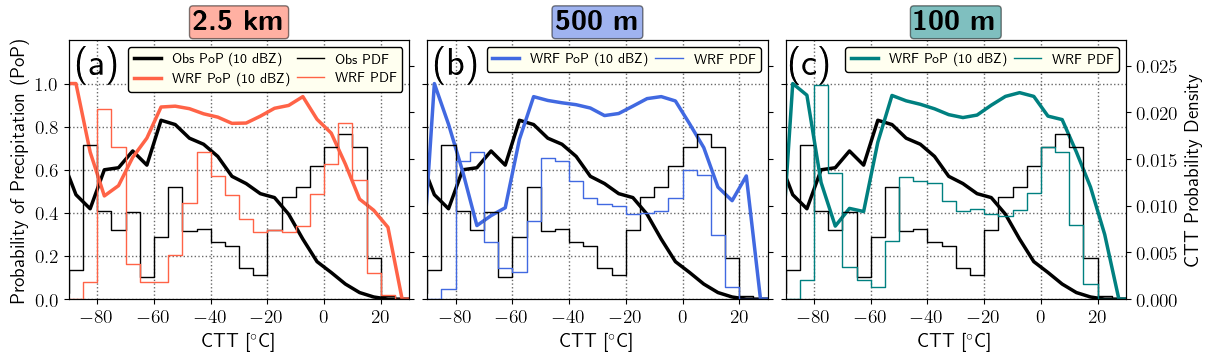

done


In [32]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-100, 45, 5)


# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(12, 3.5), constrained_layout=True)
gs = GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])  # Top-left
ax2 = fig.add_subplot(gs[1])  # Top-right
ax3 = fig.add_subplot(gs[2])   # Bottom, spanning all columns
axlist = [ax1,ax2,ax3]
labs = [r'\textbf{2.5 km}',r'\textbf{500 m}',r'\textbf{100 m}']
colors = ['tomato','royalblue','teal']
for i in range(3):
    axlist[i].set_title(labs[i],fontsize=Fontsize*1.5,y=1.01,bbox=dict(facecolor=colors[i], edgecolor='k', alpha=0.5, pad=0.125,boxstyle='round'))
#========================================================
# 2.5-km
#========================================================
ax_hist1 = ax1.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color=colors[0], lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist1, df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, color=colors[0], lw=1, linestyle='solid', label='WRF PDF')

#========================================================
# 500-m
#========================================================
ax_hist2 = ax2.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d3, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax2.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid')
ax2.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color=colors[1], lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist2, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid')
plot_pdf(ax_hist2, df_plot_wrf_ir_d3, 'ctt_tau_ir', ctt_bins, color=colors[1], lw=1, linestyle='solid', label='WRF PDF')

#========================================================
# 100-m
#========================================================
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d4, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color=colors[2], lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid')
plot_pdf(ax_hist3, df_plot_wrf_ir_d4, 'ctt_tau_ir', ctt_bins, color=colors[2], lw=1, linestyle='solid', label='WRF PDF')


# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)



# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1], ax_hist3.get_ylim()[1])

ax_hist_list = [ax_hist1,ax_hist2,ax_hist3]
# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
for ax in ax_hist_list:
    ax.set_ylim(0, max_pdf_y * 1.15)
    ax.set_yticks(np.arange(0,0.03,0.005))
ax_hist1.set_yticklabels([])
ax_hist2.set_yticklabels([])

for ax in axlist:
    ax.set_xticks(np.arange(-80,40,20))
    ax.set_ylim(0,1.2)
    ax.set_yticks(np.arange(0,1.2,0.2))
    ax.set_xlim(-90,30)
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# ==========================================================
# ax1 legend
# ==========================================================
handles_main, labels_main = ax1.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist1.get_legend_handles_labels()

all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax1.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.7, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='ivory')
# ==========================================================

# ==========================================================
# ax2 legend
# ==========================================================
handles_main, labels_main = ax2.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist2.get_legend_handles_labels()

all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax2.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.7, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='ivory')
# ==========================================================

# ==========================================================
# ax3 legend
# ==========================================================
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax3.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.7, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='ivory')
# ==========================================================


save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR_LASSO.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
plt.show()
#plt.close()
print('done')

In [24]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-100, 45, 5)


# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(12, 3.5), constrained_layout=True)
gs = GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])  # Top-left
ax2 = fig.add_subplot(gs[1])  # Top-right
ax3 = fig.add_subplot(gs[2])   # Bottom, spanning all columns
axlist = [ax1,ax2,ax3]
labs = [r'\textbf{2.5 km}',r'\textbf{500 m}',r'\textbf{100 m}']
colors = ['tomato','royalblue','teal']
for i in range(3):
    axlist[i].set_title(labs[i],fontsize=Fontsize*1.5,y=1.01,bbox=dict(facecolor=colors[i], edgecolor='k', alpha=0.5, pad=0.125,boxstyle='round'))
#========================================================
# 2.5-km
#========================================================
ax_hist1 = ax1.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color=colors[0], lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='dashed', label='Obs CTT PDF')
plot_pdf(ax_hist1, df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, color=colors[0], lw=1.5, linestyle='dashed', label='WRF CTT PDF')

#========================================================
# 500-m
#========================================================
ax_hist2 = ax2.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d3, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax2.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid')
ax2.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color=colors[1], lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist2, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='dashed')
plot_pdf(ax_hist2, df_plot_wrf_ir_d3, 'ctt_tau_ir', ctt_bins, color=colors[1], lw=1.5, linestyle='dashed', label='WRF CTT PDF')

#========================================================
# 100-m
#========================================================
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d4, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color=colors[2], lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='dashed')
plot_pdf(ax_hist3, df_plot_wrf_ir_d4, 'ctt_tau_ir', ctt_bins, color=colors[2], lw=1.5, linestyle='dashed', label='WRF CTT PDF')


# Panel labels (a, b, c)
ax1.text(0.01, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.01, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)



# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1], ax_hist3.get_ylim()[1])

ax_hist_list = [ax_hist1,ax_hist2,ax_hist3]
# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
for ax in ax_hist_list:
    ax.set_ylim(0, max_pdf_y * 1.15)
    ax.set_yticks(np.arange(0,0.03,0.005))
ax_hist1.set_yticklabels([])
ax_hist2.set_yticklabels([])

for ax in axlist:
    ax.set_xticks(np.arange(-80,40,20))
    ax.set_ylim(0,1.2)
    ax.set_yticks(np.arange(0,1.2,0.2))
    ax.set_xlim(-90,30)
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# ==========================================================
# ax1 legend
# ==========================================================
handles_main, labels_main = ax1.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist1.get_legend_handles_labels()

all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax1.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.65, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='ivory')
# ==========================================================

# ==========================================================
# ax2 legend
# ==========================================================
handles_main, labels_main = ax2.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist2.get_legend_handles_labels()

all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax2.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.65, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='ivory')
# ==========================================================

# ==========================================================
# ax3 legend
# ==========================================================
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax3.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.65, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='ivory')
# ==========================================================


save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR_LASSO.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# VIS CTT

In [33]:
# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-100, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(12, 3.5), constrained_layout=True)
gs = GridSpec(1, 3, figure=fig)

ax1 = fig.add_subplot(gs[0])  # Top-left
ax2 = fig.add_subplot(gs[1])  # Top-right
ax3 = fig.add_subplot(gs[2])   # Bottom, spanning all columns
axlist = [ax1,ax2,ax3]

#========================================================
# 2.5-km
#========================================================
ax1.set_title('WRF 2.5 km', fontsize=Fontsize*1.5)
ax_hist1 = ax1.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_vis_d2, 'ctt_tau_vis', ctt_bins, ref_thresh_single)

ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist1, df_plot_wrf_vis_d2, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

#========================================================
# 500-m
#========================================================
ax2.set_title('WRF 500 m', fontsize=Fontsize*1.5)
ax_hist2 = ax2.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_vis_d3, 'ctt_tau_vis', ctt_bins, ref_thresh_single)

ax2.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax2.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist2, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist2, df_plot_wrf_vis_d3, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

#========================================================
# 100-m
#========================================================
ax3.set_title('WRF 100 m', fontsize=Fontsize*1.5)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_vis_d4, 'ctt_tau_vis', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_vis_d4, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')


# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)


# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax1.legend(all_handles, all_labels, loc='upper right', fontsize=Fontsize*0.7, ncol=2,columnspacing=0.5,bbox_to_anchor=(1.,1.),framealpha=1,edgecolor='k',facecolor='aliceblue')
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1], ax_hist3.get_ylim()[1])

ax_hist_list = [ax_hist1,ax_hist2,ax_hist3]
# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
for ax in ax_hist_list:
    ax.set_ylim(0, max_pdf_y * 1.15)
    ax.set_yticks(np.arange(0,0.03,0.005))
ax_hist1.set_yticklabels([])
ax_hist2.set_yticklabels([])

for ax in axlist:
    ax.set_xticks(np.arange(-80,40,20))
    ax.set_ylim(0,1.2)
    ax.set_yticks(np.arange(0,1.2,0.2))
    ax.set_xlim(-90,30)
ax2.set_yticklabels([])
ax3.set_yticklabels([])


save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VIS_LASSO.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# IR CTT

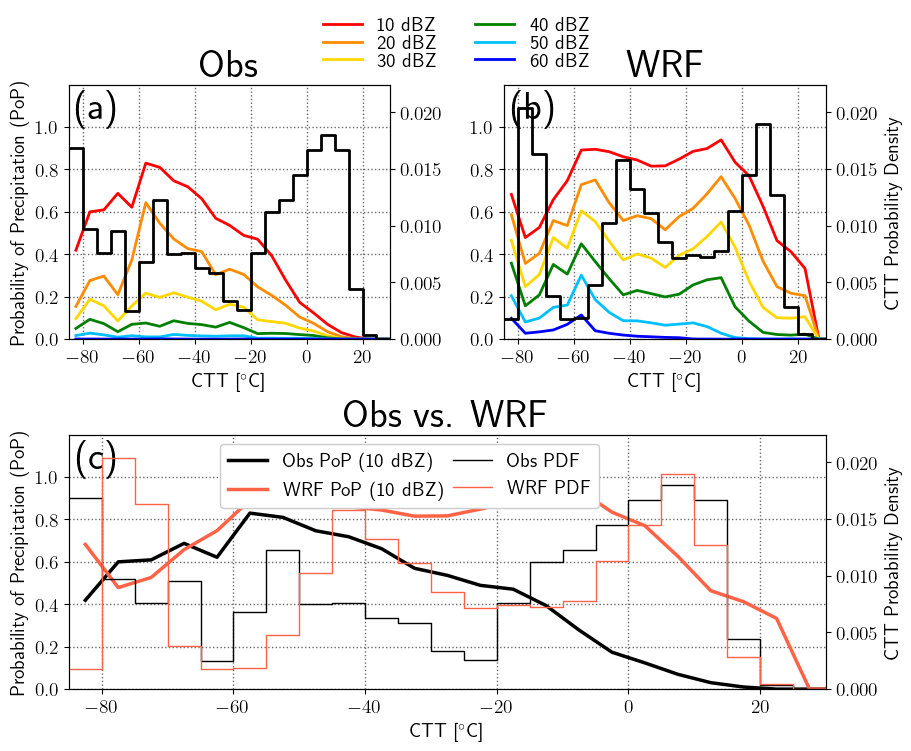

done


In [39]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_ir_d2, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
if False:
    fig.legend(handles=ax1.get_legend_handles_labels()[0], 
               labels=ax1.get_legend_handles_labels()[1], 
               fontsize=Fontsize, framealpha=False,
               bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

if True:
    fig.legend(handles=ax1.get_legend_handles_labels()[0], 
               labels=ax1.get_legend_handles_labels()[1], 
               fontsize=Fontsize, framealpha=False,
               bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR.png'
#plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

# VIS CTT

In [42]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
fig.legend(handles=ax1.get_legend_handles_labels()[0], 
           labels=ax1.get_legend_handles_labels()[1], 
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VIS.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# VIS:IR 50:50

In [43]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
fig.legend(handles=ax1.get_legend_handles_labels()[0], 
           labels=ax1.get_legend_handles_labels()[1], 
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VISIR5050.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


## Figure for Adam that shows only comparisons on both linear and logarithmic axes

In [44]:
plt.rcParams['text.usetex'] = False

In [70]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 13
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(11, 3.5), constrained_layout=True)
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax_hist1 = ax1.twinx()
ax_hist2 = ax2.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs')
ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF')
ax2.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs')
ax2.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist1, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='solid', label='WRF PDF')
plot_pdf(ax_hist2, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='solid', label='WRF PDF')

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax2.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist1.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)

ax1.grid(which='both',lw=1,c='dimgrey',ls='dotted')
ax2.grid(which='both',lw=1,c='dimgrey',ls='dotted')


# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax1.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist1.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax1.legend(handles_main, labels_main, loc='upper center', fontsize=Fontsize, ncol=1,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
ax2.legend(handles_main, labels_main, loc='upper center', fontsize=Fontsize, ncol=1,columnspacing=0.5,bbox_to_anchor=(0.45,0.6),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.)
#ax2.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
#ax2.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))

ax1.set_xlim(-80,30)
ax2.set_xlim(-80,30)

ax1.tick_params(labelsize=Fontsize)
ax2.tick_params(labelsize=Fontsize)

ax_hist1.tick_params(labelsize=Fontsize)
ax_hist2.tick_params(labelsize=Fontsize)
ax2.set_ylim(0.002,1.2)

ax2.set_yscale('log')

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR_compare_only.png'
#plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

done
